In [2]:
# Do not forget: $ poetry run jupyter notebook

%matplotlib inline
%reload_ext autoreload
%autoreload 2

import torch
DEVICE = torch.device('cpu')

# NAME = 'ladle_furnace_inference'

# **Inference: NN to estimate scattering**

## **Building scenarios with different detector configurations**

We will begin by defining 4 scenarios with different detector configurations. Each scenario corresponds to a **volume**, consisting of the configured **detectors** and a **passive volume**. 

In [3]:
from tomopt.volume import Volume
from tomopt.benchmarks.ladle_furnace import get_detector

In [4]:
# Panel span [cm]
PanelSpan = 0.7
#PanelSpan = 0.9

# muon hit detection resolution [m]
Resolution = 0.00001 # 0,01 mm (really high resolution)

PanelZ = [1.80, 1.65, 1.50, 0.30, 0.15, 0.00] # Big gap

volume_BigGapHighRes = Volume(get_detector(device=DEVICE, span=PanelSpan, res=1e5, panelZpositions=PanelZ), budget=6)
volume_BigGapHighRes

# muon hit detection resolution [m]
Resolution = 0.001 # 1 mm (common muography detector)

volume_BigGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=1e3, panelZpositions=PanelZ), budget=6)
volume_BigGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.25, 0.20] # Small gap

volume_SmallGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=1e3, panelZpositions=PanelZ), budget=6)
volume_SmallGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.15, 0.00] # Not centred

volume_NotCentred = Volume(get_detector(device=DEVICE, span=PanelSpan, res=1e3, panelZpositions=PanelZ), budget=6)
volume_NotCentred


Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

In [5]:
volume_BigGap.layers[0]

PanelDetectorLayer(
  (panels): ModuleList(
    (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
  )
)

We can visualise the layout of this in 3D.

#### a) Big gap detection panels

In [6]:
# To do: Specify panel span in .draw method

<IPython.core.display.Javascript object>


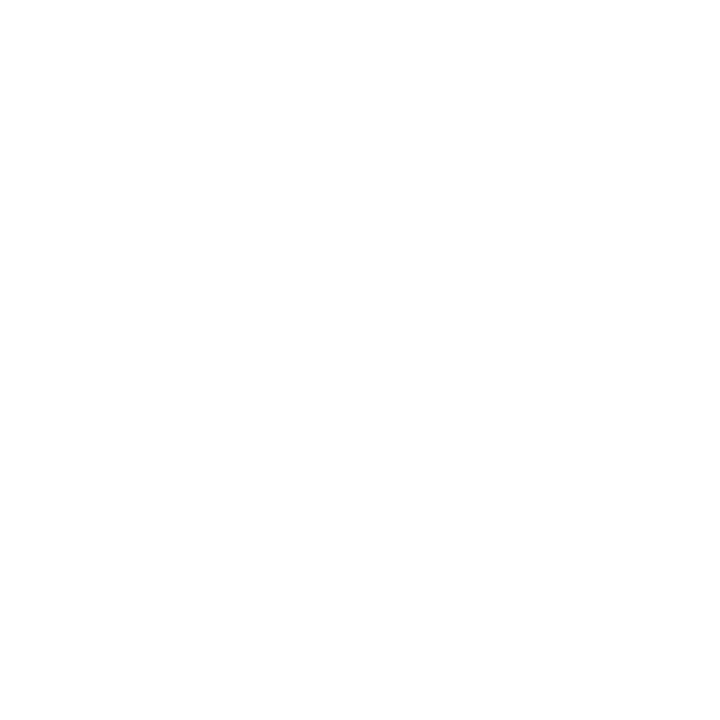

In [7]:
%matplotlib notebook
volume_BigGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### b) Small gap detection panels

<IPython.core.display.Javascript object>


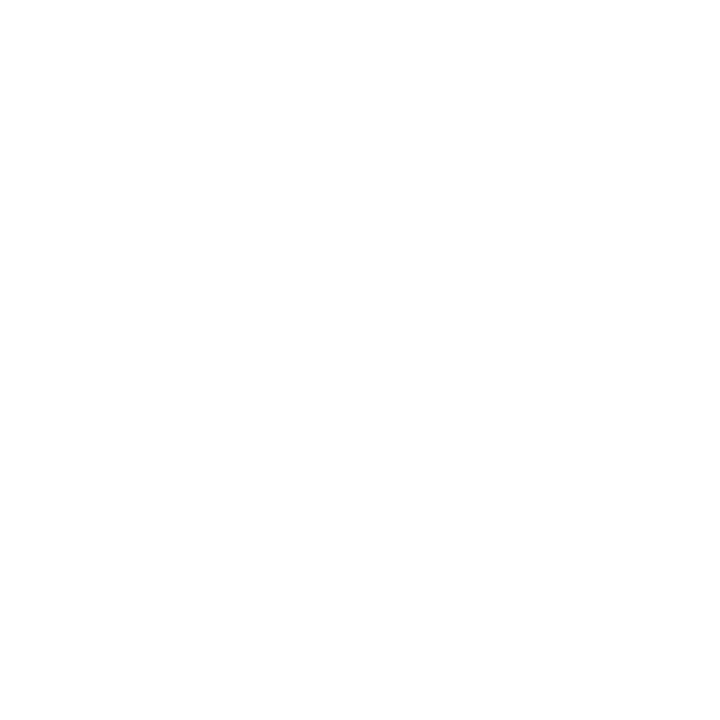

In [8]:
%matplotlib notebook
volume_SmallGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### c) Not centred detection panels

<IPython.core.display.Javascript object>


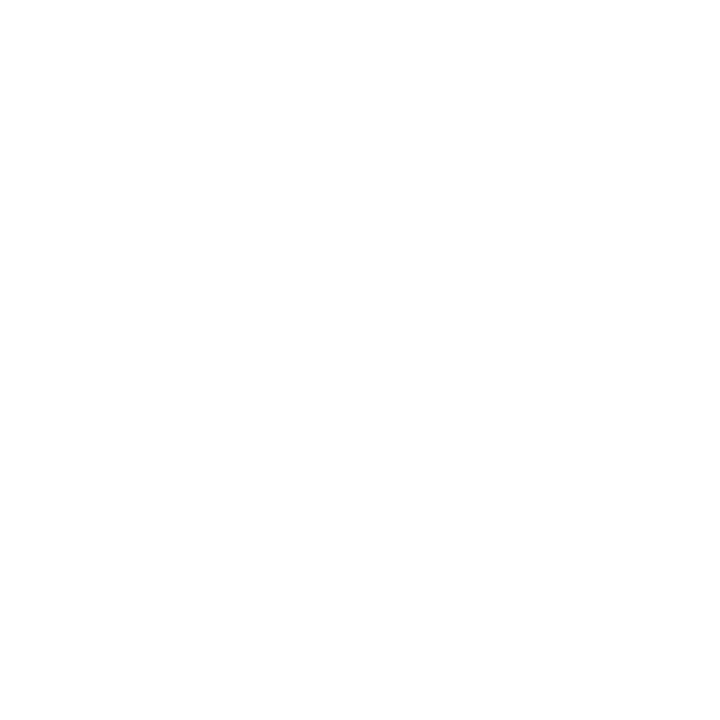

In [9]:
%matplotlib notebook
volume_NotCentred.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

In [10]:
%matplotlib inline

## **Choose scenario and define number of simulations and muon flux**

We'll continue defining the **number of simulations** we want to produce, their individual **data taking time**, and the considered **flux of muons**.

In [11]:
Simulations = 80 # number of simulations
Time = 0.1 # muography measurement time of a single simulation [min]
Flux = 6845 # considered flux of muons [muons/(min*m^2)]

# TO DO: Use generic random scenarions

# Choose scenario
Scenario = "BigGapHighRes"
# Scenario = "BigGap"
# Scenario = "SmallGap"
# Scenario = "NotCentred"

## **Generate passive volumes**

Now we'll need to define how to **generate** example **passive volumes**. The furnace ladle is made of several elements:

 - **Ladle**: a $1\times1\times1 \:[\text{m}^3]$ bucket made of solid steel.

 - **Liquid steel**: The ladle is filled with a **random amount** of liquid steel.

 - **Slag**: Above the liquid steel is a **layer** of **slag**, with a lower density that liquid steel.

 - **Air**: The rest of the ladle is filled with air.


`LadleFurnacePassiveGenerator` class will create layouts based on varying fill-heights of a furnace ladle, with varying levels of slag.

In [12]:
from tomopt.benchmarks.ladle_furnace import LadleFurnacePassiveGenerator

In [13]:
if Scenario=="BigGapHighRes":
    volume=volume_BigGapHighRes
if Scenario=="BigGap":
    volume=volume_BigGap
if Scenario=="SmallGap":
    volume=volume_SmallGap
if Scenario=="NotCentred":
    volume=volume_NotCentred


print(volume)
# volume.get_detectors(), volume.get_passives()

passive_gen = LadleFurnacePassiveGenerator(volume)

Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

We'll generate 10 volumes at a every fill-height. The 10cm of slag will be present for ever volume.

In [14]:
HEIGHTS = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
N_PASSIVES_PER_H = int(Simulations/len(HEIGHTS))

from tomopt.optimisation import PassiveYielder

trn_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)
                               for _ in range(N_PASSIVES_PER_H) for h in HEIGHTS])

## Just one
#h = 1.3
#trn_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)])

This is the amount of passive volumes generated.

In [15]:
len(HEIGHTS), N_PASSIVES_PER_H, len(trn_passives)

(8, 10, 80)

Let's visualise one of these volume layouts by repurposing one of the visualisers in TomOpt

In [16]:
SelectedVolume = 10
f,t = trn_passives.passives[SelectedVolume]
volume.load_rad_length(f, t)

In [17]:
# Get X0 of all voxels
x0 = volume.get_rad_cube()
x0.shape, x0

(torch.Size([10, 10, 10]),
 tensor([[[1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-0

In [18]:
from tomopt.plotting import plot_pred_true_x0
from tomopt.utils import x0targs_to_classtargs
from tomopt.core import X0

In [19]:
import numpy as np

In [20]:
type(1/np.sqrt(volume.get_rad_cube()))

torch.Tensor

In [21]:
volume.get_rad_cube()[:,4,4]*100

tensor([1.7820e+00, 1.9910e+00, 1.9910e+00, 1.9910e+00, 8.2110e+00, 3.0390e+04,
        3.0390e+04, 3.0390e+04, 3.0390e+04, 3.0390e+04])

true


<IPython.core.display.Javascript object>


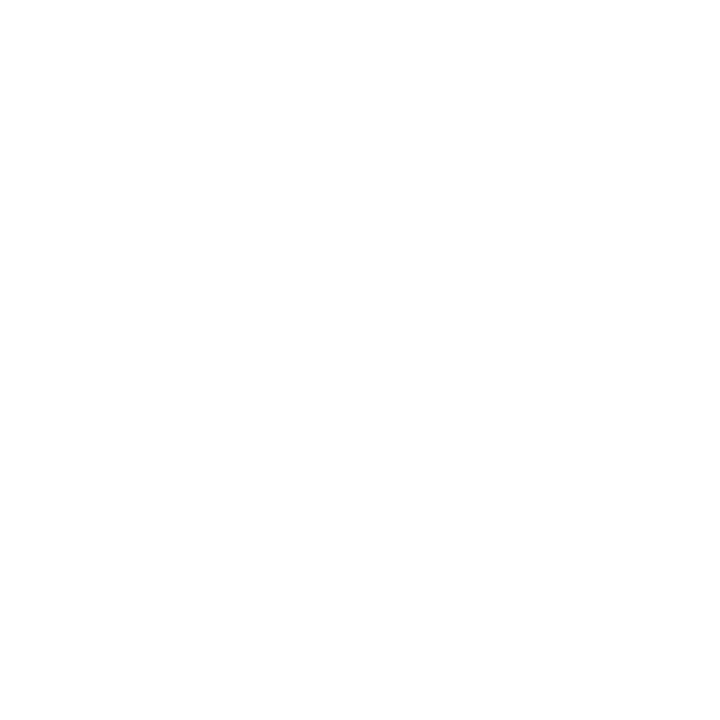

<IPython.core.display.Javascript object>


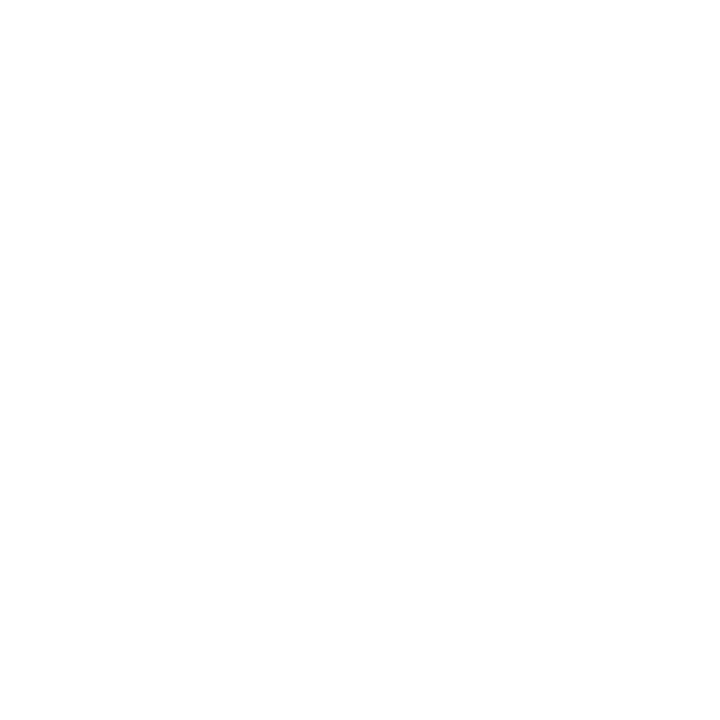

<IPython.core.display.Javascript object>


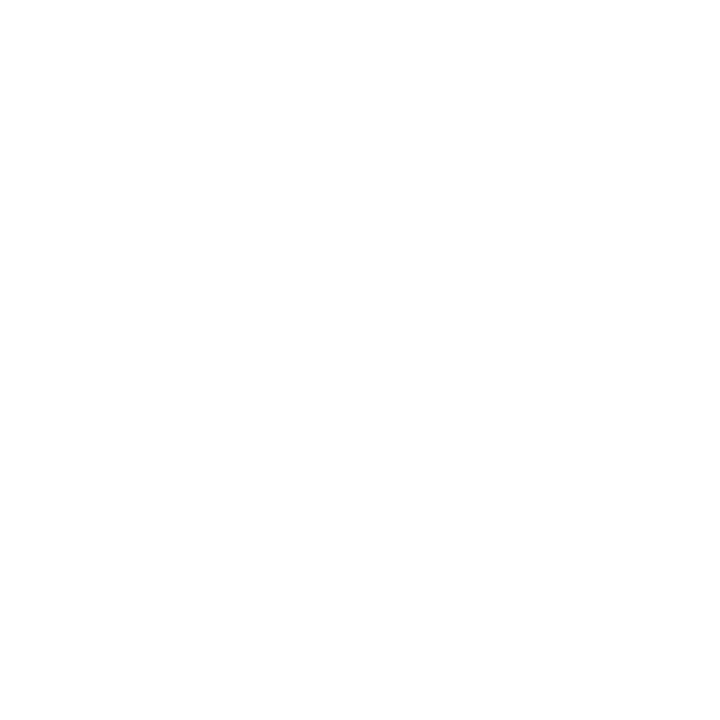

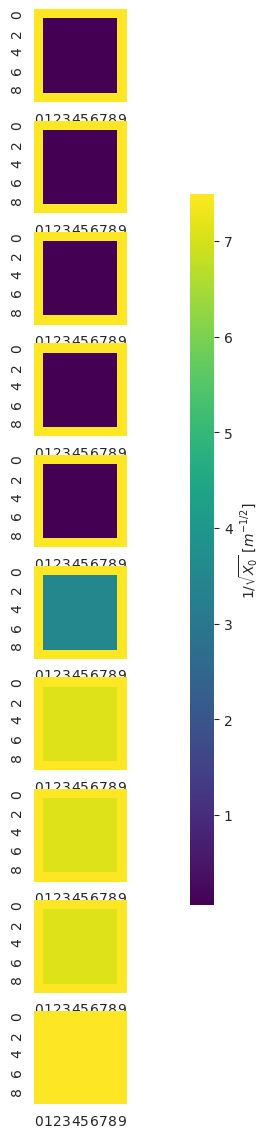

In [22]:
%matplotlib inline
# plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


In the plot of the cell above the layers of the ladle can be observed, coloured depending on the X0 of the voxel material:

 - Yellow = **ladle** (steel) 
 - Light green = **liquid steel** 
 - Dark green = **Slag** 
 - Blue = **Air**

The inverse of the square root of X0 has been plotted, a value which is approximately linear to the material density. We can see that the metals have very similar X0, but they are slightly distinguishable from the slag.

## **Muon generation and propagation**


In [23]:
from tomopt.muon import MuonGenerator2016 as MuonGenerator

In [24]:
# gen = MuonGenerator.from_volume(volume, fixed_mom=5)
gen = MuonGenerator.from_volume(volume, fixed_mom=None)
gen

Muon generator: x,y range: (-0.40192377427276926, 1.4019237742727693), (-0.40192377427276926, 1.4019237742727693). Energy sampled from 0.5087855416698359-491.5127197474533 GeV.

In [25]:
from tomopt.muon import MuonBatch

In [26]:
muons = MuonBatch(gen(2000), init_z=1.8)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(-0.3341), muons.y[0]=tensor(1.1791), muons.z[0]=tensor(1.8000), muons.theta[0]=tensor(0.7300)'

In [27]:
volume(mu=muons)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(-1.5302), muons.y[0]=tensor(2.2579), muons.z[0]=tensor(0.), muons.theta[0]=tensor(0.7300)'

In [28]:
hits = muons.get_hits()
hits

{'above': {'reco_xyz': tensor([[[-0.3340,  1.1791,  1.8000],
           [-0.3120,  1.2705,  1.6500],
           [-0.5334,  1.3589,  1.5000]],
  
          [[ 0.4600,  1.3430,  1.8000],
           [ 0.5352,  1.0651,  1.6500],
           [ 0.6105,  0.7873,  1.5000]],
  
          [[ 1.3218,  1.1481,  1.8000],
           [ 1.1261,  1.1110,  1.6500],
           [ 0.9304,  1.0736,  1.5000]],
  
          ...,
  
          [[ 1.3502,  0.5195,  1.8000],
           [ 1.8098,  0.4761,  1.6500],
           [ 1.6185,  0.4328,  1.5000]],
  
          [[ 0.8932,  0.2807,  1.8000],
           [ 0.6701,  0.4421,  1.6500],
           [ 0.4471,  0.6036,  1.5000]],
  
          [[ 0.1361,  0.2484,  1.8000],
           [ 0.0020,  0.1483,  1.6500],
           [-0.1320,  0.0481,  1.5000]]], grad_fn=<StackBackward0>),
  'gen_xyz': tensor([[[-0.3341,  1.1791,  1.8000],
           [-0.4337,  1.2690,  1.6500],
           [-0.5334,  1.3589,  1.5000]],
  
          [[ 0.4600,  1.3429,  1.8000],
           [ 0.53

In [29]:
hits['above']['reco_xyz'].shape  # [muons, detector layer, xyz]

torch.Size([2000, 3, 3])

In [30]:
hits['above']['reco_xyz'][:, 0, 0] # [all muons, 1st layer from the top, x]
hits['above']['reco_xyz'][:, 0, 1] # [all muons, 1st layer from the top, y]

tensor([1.1791, 1.3430, 1.1481,  ..., 0.5195, 0.2807, 0.2484],
       grad_fn=<SelectBackward0>)

In [31]:
import matplotlib.pyplot as plt

(array([188., 196., 200., 187., 201., 198., 205., 213., 210., 202.]),
 array([-0.40066391, -0.22055456, -0.04044521,  0.13966414,  0.3197735 ,
         0.49988285,  0.6799922 ,  0.86010158,  1.04021096,  1.22032022,
         1.40042961]),
 <BarContainer object of 10 artists>)

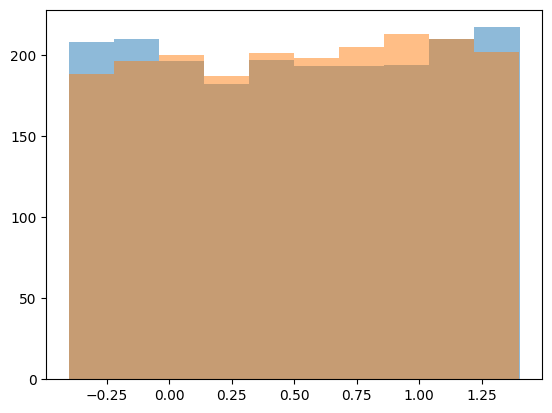

In [32]:
plt.hist(hits['above']['reco_xyz'][:, 0, 0].detach().numpy(), alpha=0.5)
plt.hist(hits['above']['reco_xyz'][:, 0, 1].detach().numpy(), alpha=0.5)

In [33]:
from tomopt.inference import ScatterBatch

In [34]:
%%time
sb = ScatterBatch(mu=muons, volume=volume)

CPU times: user 128 ms, sys: 4.23 ms, total: 132 ms
Wall time: 349 ms


In [35]:
len(sb.hit_effs[0, :, 0])
sb.hit_effs.flatten().shape


E = sb.hit_effs[:, 0, 0]
for i in range(1, len(sb.hit_effs[0, :, 0])):
    E = E + sb.hit_effs[:, i, 0]
    
E = E/len(sb.hit_effs[0, :, 0])
E = E.detach().numpy()

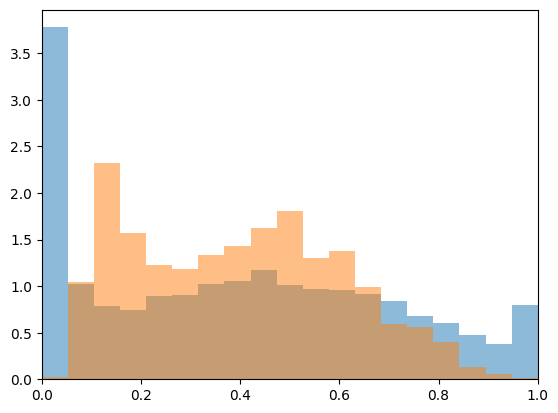

In [36]:
# Efficiency of every muon in each detector panel
plt.hist(sb.hit_effs.flatten().detach().numpy(), alpha=0.5, density=True, bins=np.linspace(0,1,20))
#plt.show()

# Average efficiency of every muon in all the detector panels
plt.hist(E, alpha=0.5, density=True, bins=np.linspace(0,1,20))

plt.xlim([0, 1])
plt.show()

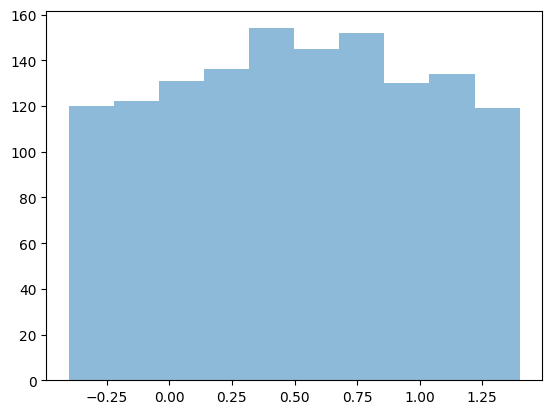

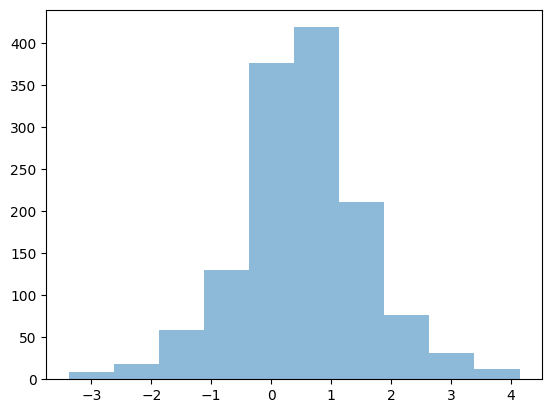

(torch.Size([1343, 3, 3]), torch.Size([1343, 3, 3]))

In [37]:
plt.hist(sb.above_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()
plt.hist(sb.below_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()

sb.above_gen_hits.shape, sb.below_gen_hits.shape

In [38]:
%%time
sb.poca_xyz, sb.poca_xyz_unc

CPU times: user 19 s, sys: 11.1 s, total: 30.1 s
Wall time: 16.8 s


(tensor([[-1.3179,  2.0663,  0.3196],
         [ 0.7574,  0.2444,  1.2069],
         [ 0.3753,  0.9674,  1.0775],
         ...,
         [-1.1208,  1.3188,  4.5633],
         [ 0.0503,  0.8908,  1.2330],
         [-1.1501, -0.7124,  0.3608]], grad_fn=<AddBackward0>),
 tensor([[1.3499e-01, 1.2189e-01, 2.0324e-01],
         [3.1337e-02, 1.1582e-01, 6.2540e-02],
         [8.3529e-04, 1.9139e-04, 6.0771e-04],
         ...,
         [1.2964e+02, 4.1944e+01, 1.4498e+02],
         [4.5264e-03, 3.3366e-03, 3.3354e-03],
         [1.7804e-01, 1.3307e-01, 1.9928e-01]], grad_fn=<SqrtBackward0>))

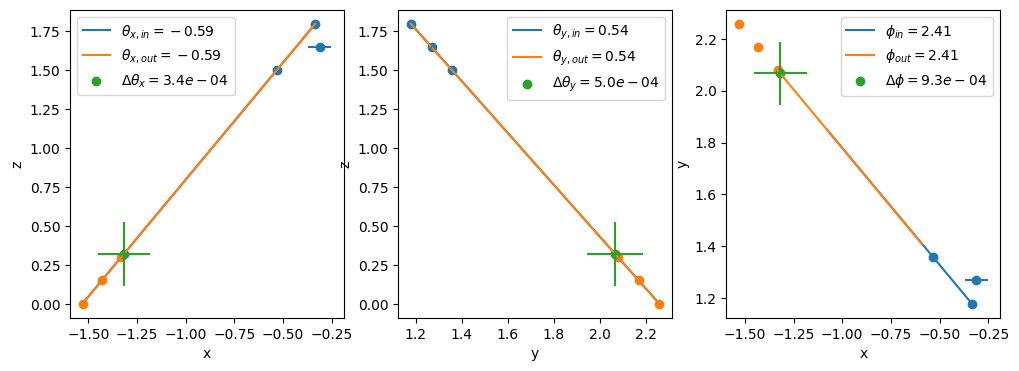

In [39]:
sb.plot_scatter(idx=0)

## **Inference: NN to estimate scattering**


### Inputs

In [40]:
M = 0 # selected muon

In [41]:
hits['above']['reco_xyz'][M, 0, :] # [muon, 1st layer from the top, x-y-z]

tensor([-0.3340,  1.1791,  1.8000], grad_fn=<SliceBackward0>)

In [42]:
hits['above']['reco_xyz'][M, 2, :] # [muon, 3rd layer from the top, x-y-z]

tensor([-0.5334,  1.3589,  1.5000], grad_fn=<SliceBackward0>)

In [43]:
hits['below']['reco_xyz'][M, 0, :] # [muon 0, 1st layer from the top, x-y-z]

tensor([-1.3309,  2.0780,  0.3000], grad_fn=<SliceBackward0>)

In [44]:
hits['below']['reco_xyz'][M, 2, :] # [muon 0, 1st layer from the top, x-y-z]

tensor([-1.5301,  2.2578,  0.0000], grad_fn=<SliceBackward0>)

In [45]:
muons.mom[M]

tensor(0.9091)

### NN

In [46]:
hits['above']['reco_xyz'][:, 0, :].shape # panel 0

torch.Size([2000, 3])

In [47]:
hits['above']['reco_xyz'][:, 2, :].shape # panel 2

torch.Size([2000, 3])

In [48]:
hits['below']['reco_xyz'][:, 0, :].shape # panel 0

torch.Size([2000, 3])

In [49]:
hits['below']['reco_xyz'][:, 2, :].shape # panel 2

torch.Size([2000, 3])

In [58]:
muons.mom.shape

torch.Size([1343])

Why are less muons than hits? muons are those hits that also cross the passive vol??

In [60]:
hits['above']['reco_xyz'][:, 0, 0:2].shape # only x and y

torch.Size([2000, 2, 3])

In [62]:
hits['below']['reco_xyz'][:, 0, 0:2].shape # only x and y??

torch.Size([2000, 2, 3])

In [77]:
X_tensor = torch.cat((hits['above']['reco_xyz'][:, 0, 0:2], 
                      hits['above']['reco_xyz'][:, 2, 0:2],
                      hits['below']['reco_xyz'][:, 0, 0:2],
                      hits['below']['reco_xyz'][:, 2, 0:2]), 1)

In [78]:
X_tensor.shape

torch.Size([2000, 8])

In [79]:
SelectedVolume = 10
f,t = trn_passives.passives[SelectedVolume]
volume.load_rad_length(f, t)

In [80]:
# Get X0 of all voxels
x0 = volume.get_rad_cube()
x0.shape, x0

(torch.Size([10, 10, 10]),
 tensor([[[1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-0

(array([320.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,  64.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0., 192.,   0.,   0.,   0.,   0.,
        424.]),
 array([0.05736337, 0.13170083, 0.20603828, 0.28037575, 0.3547132 ,
        0.42905065, 0.50338811, 0.57772559, 0.65206307, 0.72640049,
        0.80073798, 0.8750754 , 0.94941288, 1.02375031, 1.09808779,
        1.17242527, 1.24676275, 1.32110023, 1.3954376 , 1.46977508,
        1.54411256, 1.61845005, 1.69278753, 1.

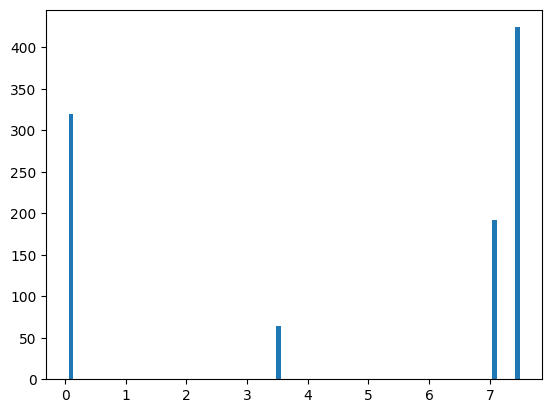

In [87]:
plt.hist(1/np.sqrt(x0).flatten(), bins=100)

In [88]:
y_tensor = x0.flatten()

In [89]:
y_tensor.shape

torch.Size([1000])

### Get the x0 of all the passive vols

In [55]:
import torch.nn as nn
import torch.optim as optim

# SPLIT dataset into training and testing sets

#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

# Assume X_tensor and y_tensor are your full datasets
from torch.utils.data import TensorDataset, random_split

In [ ]:
dataset = TensorDataset(X_tensor, y_tensor)

# 80% train, 20% test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# If needed as tensors:
X_train, y_train = train_dataset[:][0], train_dataset[:][1]
X_test, y_test = test_dataset[:][0], test_dataset[:][1]

In [56]:
# Example synthetic data
N_SAMPLES = 500
X = torch.randn(N_SAMPLES, 13)
y = torch.randn(N_SAMPLES, 1000)

# Optionally normalize inputs and outputs
#scaler_X = StandardScaler()
#scaler_y = StandardScaler()
#X_np = scaler_X.fit_transform(X.numpy())
#y_np = scaler_y.fit_transform(y.numpy())

X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.float32)

# Split into train and test
#X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2)

# Define model
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1000)
        )

    def forward(self, x):
        return self.model(x)

model = RegressionNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_test), y_test)
        print(f"Epoch {epoch+1}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")



NameError: name 'X_np' is not defined

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seed for reproducibility
torch.manual_seed(42)

# Simulated dataset: 500 samples, 13 inputs → 1000 outputs
X_tensor = torch.randn(500, 13)
y_tensor = torch.randn(500, 1000)

# Optional: Normalize data (standardization)
X_mean, X_std = X_tensor.mean(0, keepdim=True), X_tensor.std(0, keepdim=True)
y_mean, y_std = y_tensor.mean(0, keepdim=True), y_tensor.std(0, keepdim=True)

X_tensor = (X_tensor - X_mean) / (X_std + 1e-8)
y_tensor = (y_tensor - y_mean) / (y_std + 1e-8)

# Train/test split using torch
n_samples = X_tensor.size(0)
perm = torch.randperm(n_samples)
split_idx = int(0.8 * n_samples)
train_idx, test_idx = perm[:split_idx], perm[split_idx:]

X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

# Define the model
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1000)
        )

    def forward(self, x):
        return self.net(x)

model = RegressionNN()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    preds = model(X_train)
    loss = criterion(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_preds = model(X_test)
            val_loss = criterion(val_preds, y_test)
        print(f"Epoch {epoch+1:>2}: Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}")


Epoch 10: Train Loss = 0.9859 | Val Loss = 1.0077
Epoch 20: Train Loss = 0.9623 | Val Loss = 1.0186
Epoch 30: Train Loss = 0.9355 | Val Loss = 1.0371
Epoch 40: Train Loss = 0.9078 | Val Loss = 1.0541
Epoch 50: Train Loss = 0.8757 | Val Loss = 1.0708
